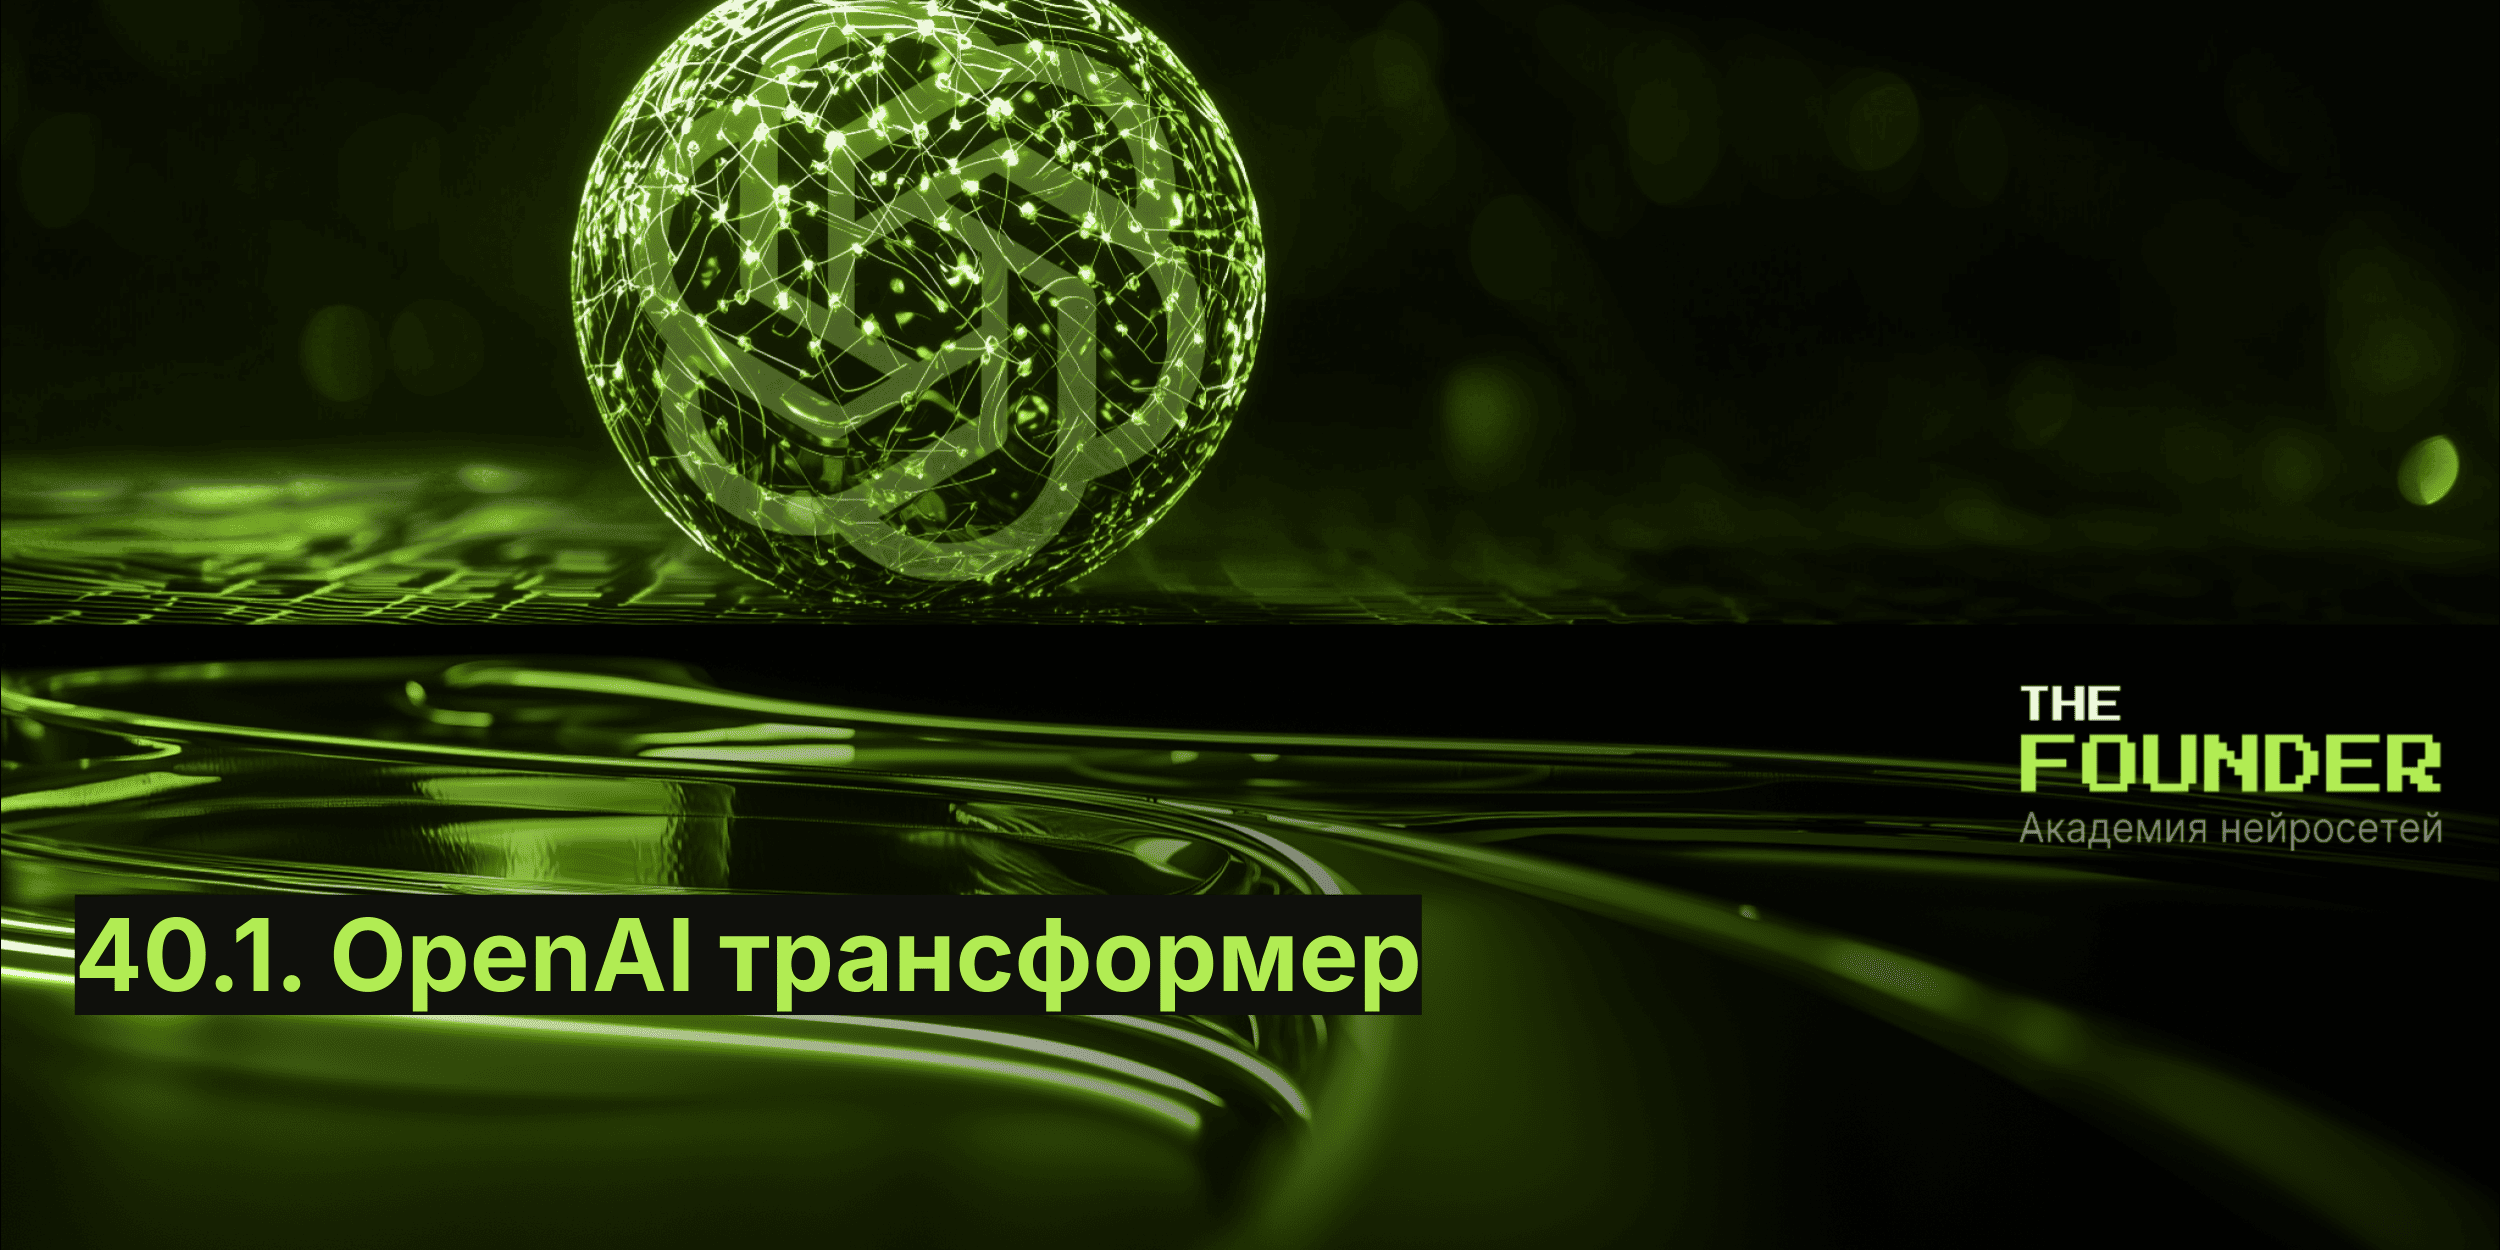

**Навигация по уроку**
1. OpenAI Трансформер
2. [Обучение GPT-модели](https://colab.research.google.com/drive/1-cYTyr3KVz-oZ4EdAsGmmmw-N7qebAdZ)
3. [Домашняя работа](https://colab.research.google.com/drive/1SMuggK6iBQmYcX6xnq5t3ilLg1kQ4UmR)

**В данном уроке:**
1. Мы продолжим узучать трансформеры и познакомимся с архитектурой OpenAI Transformer.
2. Узнаем, что общего у GPT и OpenAI Transformer.
2. Узнаем, как мы можем использовать GPT в своих проектах.

В прошлых уроках мы узнали, что сначала миром NLP правили рекуррентные сети (RNN, LSTM, GRU, и Bi-LSTM), потом появился механизм внимания — attention, который, применительно к рекуррентным сетям, давал хорошие результаты. После ребята из Google предположили, что attention настолько крутой, что справится и без RNN. Так появился первый трансформер в статье Attention Is All You Need.

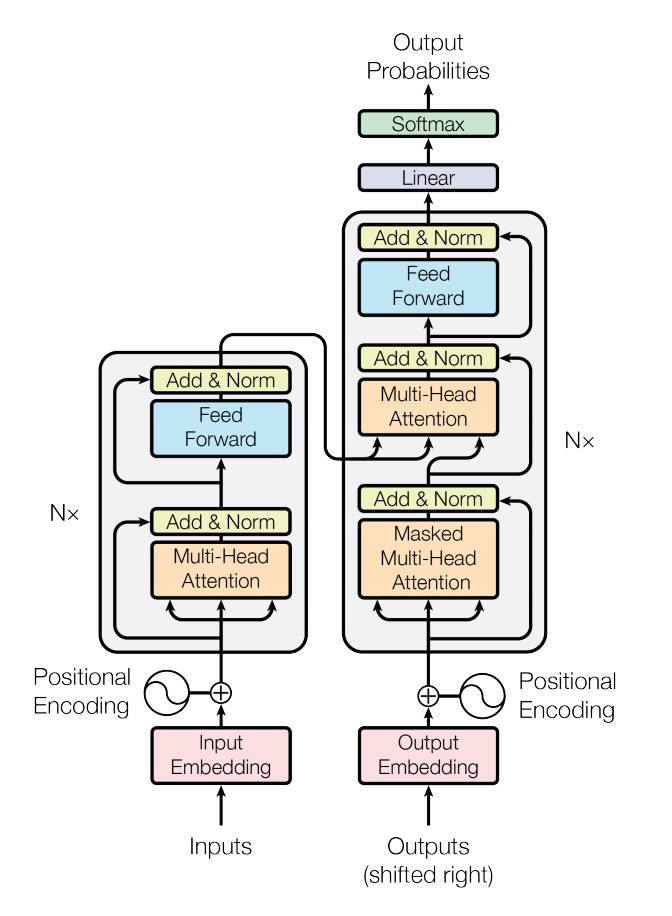

**Рис. 1. Классический трансформер**

Это был классический трансформер (см. рис. 1), который состоял из кодировщика и декодировщика, каждый из которых представляет из себя стек блоков кодировщиков или декодировщиков. Такая архитектура идеально подходила для задач машинного перевода.

Дальнейшие исследования показали, что можно отбросить декодировщик или кодировщик и использовать только один стек блоков Трансформера, надстраивая эти блоки столько, сколько вообще возможно, скармливая им огромные объемы текстовых данных для обучения и выполняя громадные объемы вычислений на них.

На рис. 2. изображена структура сети [OpenAI Transformer](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf) с одним блоком декодировщика (выделен серым фоном). Размер модели определяется числом повторений таких блоков. Структура декодировщика нам знакома: self-attention (внутреннее внимание), нормализация, feed-forward и residual connections (остаточные соединения).

Многие исследовательские группы пошли по пути создания сразу нескольких моделей, с разным числом блоков и обучением их на одних и тех же датасетах. Забегая вперед, стоит сказать, что, например, модель GPT-2, была представлена сразу несколькими "размерами":

* GPT-2 Small       - 12 блоков декодировщиков;
* GPT-2 Medium      - 24 блока декодировщиков;
* GPT-2 Large       - 36 блоков декодировщиков;
* GPT-2 Extra Large - 48 блоков декодировщиков.

## GPT под капотом

**Так что же такое GPT?**
Это нейронная сеть для генерации следующего слова в тексте по входной фразе. То есть GPT - это языковая модель, основанная на архитектуре трансформер и обученная в **Self-Supervised** режиме на большом объеме текстовых данных.

**Self-Supervised Learning (или unsupervised)** - режим обучения моделей, при котором задача обучения не требует дополнительной разметки и формируется исходя из внутренней структуры самих объектов, либо из базовых знаний об объектах.


Так как на ахитектуре трансформеров можно построить множество типов сетей, то конкретизируем, что такое GPT. А именно, GPT - предобученная генеративная сеть на базе декодировщика, работающая по следующей схеме (см. рис. 2):

1. Входной текст $x$ токенизируется в последовательность чисел (токенов).
2. Список токенов проходит через слой Embedding и превращается в список эмбеддингов $xW_e$.
3. К каждому эмбеддингу $xW_e$ прибавляется positional embedding (позиционный эмбединг) $W_p$.
4. Далее этот список эмбеддингов $xW_e+W_p$ пропускается через стек одинаковых блоков (Transformer Decoder Block).
5. После прохождения эмбеддингов через все блоки, эмбеддинг соответствующий последнему токену $h_L$ проходит через слой Embedding, веса которого транспонированы по отношению к первичному входному эмбеддингу $W_e^T$. На математическом языке - вектор эмбеддинга умножается на транспонированную матрицу весов) $h_LW_e^T$.
6.  Применяется `softmax` и получается распределение вероятностей следующего токена.
7. Из этого распределения выбираем следующий токен (например, с помощью функции `argmax`).
8. Токен добавляется к входному тексту и повторяем шаги 1-7.

Такая схема была предложена в статье [Improving Language Understanding by Generative Pre-Training (2018)](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf), которая положила начало GPT моделям. Также, чтобы не запутаться в "зоопарке" трансформеров, ссылаясь на модель изложенную в данной статье, принято называть ее OpenAI Transformer.




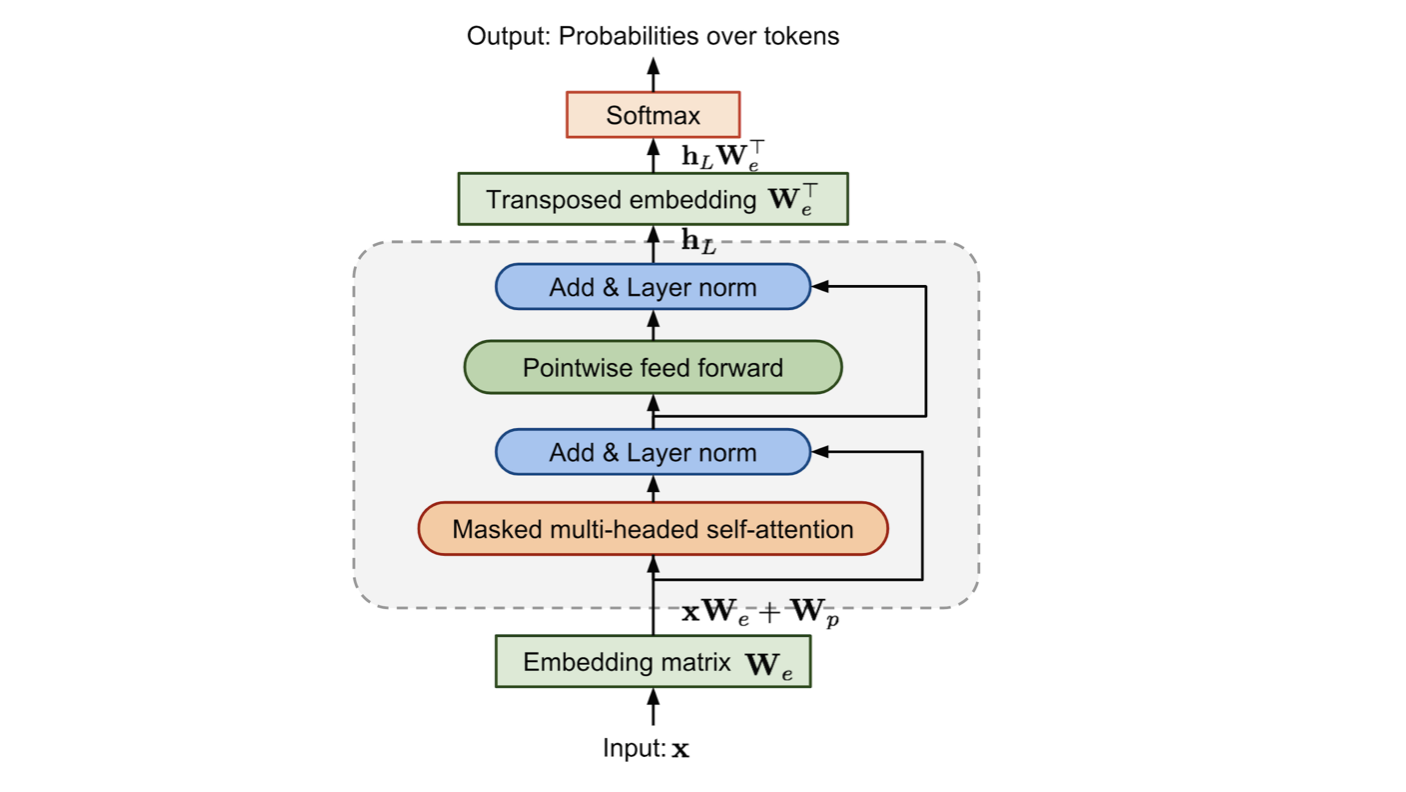

**Рис. 2. Структура блока GPT**

### Токенизация

Мы уже знаем, что ИИ работает с числами, а не с текстами, поэтому нам необходима преобразовать текст в последовательность чисел, прежде чем его подавать на вход ИИ.

Мы можем использовать различные методы токенизации. Самый простой способ, и мы так уже делали, - назначить каждому уникальному слову свое число — токен, а затем заменить все слова в тексте на эти числа.
Здесь проблема очевидная: слов очень много, а значит словари будут получаться гигантскими!

Другой подход - разбить текст не на слова, а на отдельные буквы (char-level tokenization), тогда в словаре будет всего несколько десятков токенов, но в таком случае, получим другую проблему, уже сам текст после токенизации будет слишком длинным, а это затрудняет обучение.

Поэтому нужно выбирать, что-то среднее. Т.е. разбивать слова на наиболее общие части и представлять их полные версии как комбинации этих кусков. Такой способ токенизации называется BPE (Byte Pair Encoding).

В OpenAI взяли этот средний подход и немного модифицировали, получилась byte-level BPE токенизация. Эта модификация BPE работает не с текстом, а напрямую с его байтовым представлением. Использование такого трюка позволило сжать словарь до ~50k токенов при том, что с его помощью все еще можно выразить любое слово на любом языке мира (и даже эмодзи).

Так давайте проверим как работает токенизация BPE с помощью уже известной нам библиотеки `transformers` от HuggingFace.

In [ ]:
!pip install transformers # Сначала установим библиотеку transformers

С моделями из библиотеки трансформер можно работать как с помощью фреймворка tensorflow, как мы делали для Bert, и имена моделей и токенизатора начинались с префикса TF, так и с помощью pytorch (модели без префикса).

Для работы с моделями GPT, удобно использовать токенизатор GPT2Tokenizer и класс модели GPT2LMHeadModel. С помощью них, мы можем загрузить предобученные модели.

Для примера давайте возьмем русскоязычную версию GPT от Сбера. Для загрузки и инициализации модели и токенизатора достаточно передать имя требуемой модели из всего набора HuggingFace:

```python
model_name = "sberbank-ai/rugpt3large_based_on_gpt2"

```

Также укажем библиотеке pytorch, что вычисления мы будем проводить на графическом процессоре с поддержкой `cuda`.

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
DEVICE = torch.device("cuda:0")

# Для большей наглядности будем работать с русскоязычной версией GPT от Сбера.
# Ниже находятся команды для загрузки и инициализации модели и токенизатора.
model_name = "sberbank-ai/rugpt3large_based_on_gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name).to(DEVICE)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/622 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

Токенизируем фразу и преобразуем обратно, чтобы понять какие части слова вошли в токен:

In [ ]:
# Токенизации
text = "Съешь ещё этих мягких французских булок, да выпей же чаю" # Изначальные текст
tokens = tokenizer.encode(text, add_special_tokens=False) # Процесс токенизации с помощьюю токенайзера ruGPT-3
decoded_tokens = [tokenizer.decode([token]) for token in tokens] # Обратная поэлементая токенизация

print("Текст:", text)
print("Токены: ", tokens)
print("Декодированные токены: ", decoded_tokens)

Текст: Съешь ещё этих мягких французских булок, да выпей же чаю
Токены:  [563, 691, 1048, 2072, 1967, 39961, 25292, 4036, 2460, 16, 581, 4093, 355, 575, 28436]
Декодированные токены:  ['С', 'ъ', 'ешь', ' ещё', ' этих', ' мягких', ' французских', ' бу', 'лок', ',', ' да', ' вып', 'ей', ' же', ' чаю']


Фраза выбрана неслучайно. Это панграмма, то есть предложение, в котором представлены все буквы русского алфавита. Панграммы используются для проверки работоспособности печатающих устройств и демонстрации шрифтов. Мы же решили использовать панграмму для демонстрации токенизации BPE.

Так как GPT использует byte-level токенизатор, то не для любого токена найдется существующий символ или слово. Некоторые токены существуют только в комбинациях.

Например, один иероглиф состоит из трех токенов:

In [ ]:
# По отдельности эти 3 токена не декодируются
print(tokenizer.decode([167]))
print(tokenizer.decode([245]))
print(tokenizer.decode([256]))

# Вместе они образуют иероглиф
print(tokenizer.decode([167, 245, 256]))

�
�
�
撝


### Подходы к генерации текста

В этой части урока речь пойдет о выборе токена для следующей итерации. Языковая модель выдает распределение вероятностей следующего токена. Раз мы говорим о вероятности, то способов выбора существует несколько.

Давайте выберем некоторую фразу и применим к ней различные подходы для получения ее продолжения.

In [ ]:
text = "Физика - это наука"
input_ids = tokenizer.encode(text, return_tensors="pt").to(DEVICE)

#### Greedy Search
Самый простой способ — это аргмаксная генерация (greedy search), когда мы каждый раз выбираем токен, у которого максимальная вероятность. Это не самый лучший метод, так как в таком случае генерация застревает в локальных минимумах и часто выдаёт повторяющиеся фрагменты, например `the the the the ...`.

In [ ]:
# Пример аргмаксного сэмплирования
out = model.generate(input_ids, do_sample=False, max_length=30)

# Декодирование токенов
generated_text = list(map(tokenizer.decode, out))[0]
print()
print(generated_text)


Физика - это наука о законах природы, о законах движения и взаимодействия тел, о законах сохранения энергии и импульса, о закона


#### Beam Search
Чуть более сложный и качественный способ сэмплирования — это beam search. В этом случае на каждом шаге мы выбираем не только один самый вероятный токен, а сразу несколько (`beam-size`), и дальше продолжаем поиск для каждого из выбранных токенов. Таким образом мы разветвляем пути генерации, получая несколько вариантов сгенерированного текста. В итоге можно выбрать тот вариант, у которого выше уверенность в реалистичности текста. Такая генерация обладает хорошей когерентностью (связностью). Однако этот подход приводит к более роботизированным текстам. Говорят, что им не хватает "человечности"! Также данный подход может приводить к повторяющим фрагментам в сгенерированном тексте.

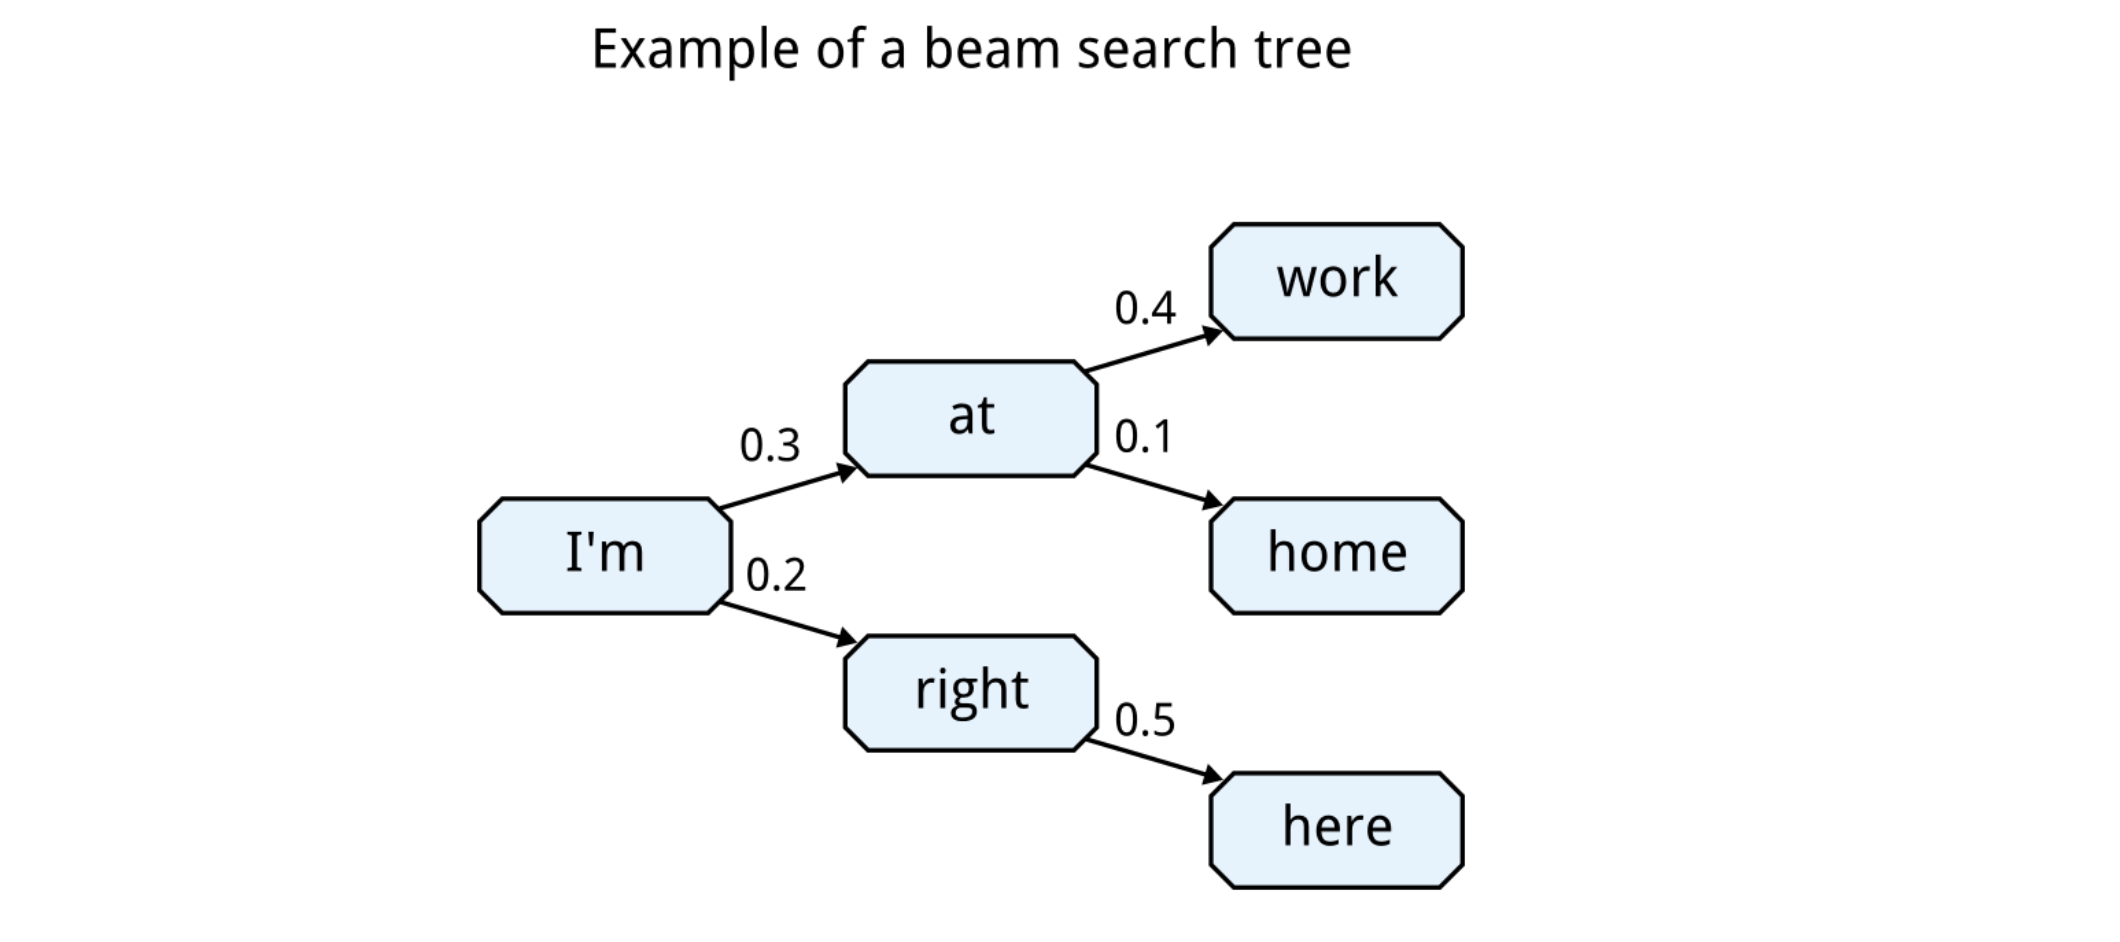

In [ ]:
# Пример генерации с помощью beam-search
out = model.generate(input_ids, do_sample=False, num_beams=5, max_length=30)

# Декодирование токенов
generated_text = list(map(tokenizer.decode, out))[0]
print()
print(generated_text)


"Физика" - это наука, изучающая физические процессы, происходящие в твердых телах и жидкостях, а также явления, связанные


#### Сэмплирование с температурой
Чтобы добавить тексту непредсказуемости и "человечности", можно использовать вероятностное сэмплирование с температурой. При такой генерации мы берем не самый вероятный токен, а выбираем его "случайно" с учетом распределения вероятностей. Параметр температуры позволяет контролировать степень случайности. При температуре меньше 1 и стремящейся к 0, этот метод будет приводить к выбору, как в аргмаксном сэмплировании, а при очень большой температуре токены будут выбираться совсем наугад. Обычно хорошо работает температура в диапазоне `0.8 - 2.0`. Формула модификации распределения вероятностей очень похожа на формулу распределения Больцмана. Чем выше температура системы тем больше "размазывается" распределение вероятностей её возможных состояний, отсюда слово "температура".

`p'=softmax(log(p)/t)`

Но у этого метода есть и минусы, ведь случайная природа генерации будет иногда приводить к совсем уж некорректным результатам, хоть и редко.

Приведем пример. Пусть в некоторой LLM моделе мы получили для соответствующих слов логиты (ненормализованные вероятности):

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.DataFrame(
    {"Word": ["donut", "cake", "apple", "juice", "book"],
     "Logit": [11, 10.5, 10.8, 10.7, 8]}
)

Наиболее вероятное значение donut (пончик). При $T = 1$ мы получаем классический softmax. Далее при уменьшении $T$, значение логитов становиться более "резким" (более вероятные увеличиваются, менее вероятные уменьшаются).

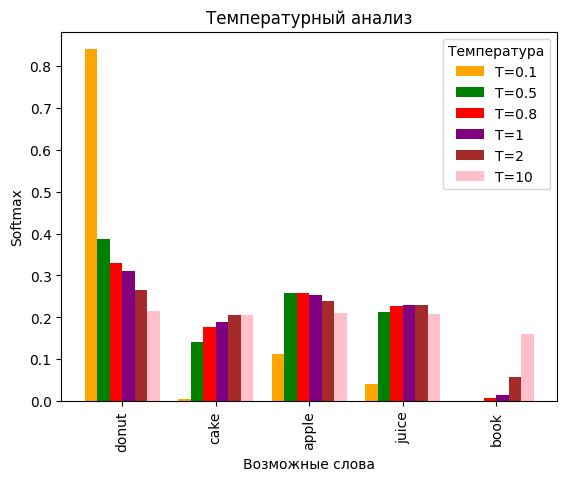

In [ ]:
# Вычислим softmax для различных температур
temperatures = [0.1, 0.5, 0.8, 1, 2, 10]
for temp in temperatures:
    col_name = f"T={temp}"
    df[col_name] = np.round(np.exp(df.Logit / temp) / np.sum(np.exp(df.Logit / temp)), 4)

# Удалим "Logit" колонку
df_plot = df.drop("Logit", axis=1)

# Установим цвета для колонок
colors = ['orange', 'green', 'red', 'purple', 'brown', 'pink']

# Строим график
df_plot.set_index("Word").plot(kind="bar", color=colors, width=0.8)

# Кастомизируем график
plt.xlabel('Возможные слова')
plt.ylabel('Softmax')
plt.title('Температурный анализ')
plt.legend(title="Температура", bbox_to_anchor=(1, 1))
plt.show()

При увеличении температуры больше 1, вероятности начинают выравниваться и при больших температурах, практически выбор токена становиться равновероятным!

In [ ]:
# Пример вероятностного сэмплирования
out = model.generate(input_ids, do_sample=True, temperature=1.3, max_length=30)

# Декодирование токенов
generated_text = list(map(tokenizer.decode, out))[0]
print()
print(generated_text)


"Физика" - это наука о природе и Вселенной, об устройстве мира, в том числе и окружающего, которая, с одной стороны, изучает


#### Сэмплирование с Ограничением Маловероятных Токенов (Nucleus sampling)
Для запрета сэмплирования совсем уж некорреткных токенов вводят `top-k` или `top-p` ограничения. В этом случае генерация тоже происходит случайным образом, но мы заранее отсекаем все маловероятные токены. В случает `top-k` мы просто зануляем все вероятности кроме `k` самых вероятных. А в случае `top-p` мы оставляем такой минимальный сет токенов, чтобы сумма их вероятностей была не больше `p`.

`top-p` ограничение называют **Nucleus Sampling**.

In [ ]:
# Пример вероятностного сэмплирвоания с ограничением
out = model.generate(input_ids,
                     do_sample=True,
                     temperature=1.3,
                     top_k=20,
                     top_p=0.8,
                     max_length=30,
                    )
# Декодирование токенов
generated_text = list(map(tokenizer.decode, out))[0]
print()
print(generated_text)


"Физика" - это наука, изучающая движение и взаимодействие физических тел. В частности, это науки о движении, в частности - о движении


## Сравнение поколений GPT


### SotA

Термин SOTA, который расшифровывается как “State of the Art”, обычно используется в области машинного обучения для обозначения наиболее эффективной модели или алгоритма в данной задаче или предметной области. Отражает самый высокий на данный момент уровень производительности, достигнутый исследователями в этой конкретной области. SOTA служит эталоном, с которым сравниваются другие модели и алгоритмы.

SOTA представляет собой передовую технологию или методику, которая превосходит все предыдущие подходы и позволяет достичь превосходных результатов с точки зрения точности, скрупулезности, запоминаемости и других показателей оценки. Это золотой стандарт, который исследователи стремятся превзойти, стремясь к прорывам в своих областях.

Что отличает SOTA от предыдущих подходов, так это ее способность расширять границы того, что считается возможным в конкретной задаче машинного обучения. По мере развития технологий и появления новых наборов данных SOTA постоянно развивается и совершенствуется.

SOTA может варьироваться в разных областях машинного обучения, поскольку каждая область имеет свой собственный набор задач и критериев оценки. Например, в компьютерном зрении SOTA может относиться к наиболее точной модели распознавания изображений, тогда как в обработке естественного языка она может обозначать модель с наивысшими возможностями генерации языка.

Чтобы определить, соответствует ли модель или алгоритм критериям SOTA, необходимы тщательная оценка и сравнение. Исследователи обычно используют базовые наборы данных и стандартизированные оценочные метрики для оценки эффективности различных подходов. Цель состоит в том, чтобы определить метод, который обеспечивает наивысший уровень точности или дает наиболее ценную информацию для решения данной задачи.

Определяя SOTA и стремясь к ее достижению, исследователи вносят свой вклад в развитие машинного обучения и стимулируют инновации в различных областях. Стремление к SOTA способствует здоровой конкуренции среди исследователей и стимулирует разработку новых методов и методологий.

Кратко рассмотрим 4 поколени GPT. И по традиции начнем с обзора оригинальных статей.





**Предлагаем для ознакомления оригинальные статьи про 4 поколения GPT:**
* [Improving Language Understanding by Generative Pre-Training (2018)](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)
* [Language Models are Unsupervised Multitask Learners (2019)](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
* [Language Models are Few-Shot Learners (2020)](https://arxiv.org/pdf/2005.14165.pdf)
* [GPT-4 Technical Report](https://cdn.openai.com/papers/gpt-4.pdf)

### GPT-1
 **GPT — Generative Pretraining of Transformers.** Первая версия этой модели от OpenAI состояла из 12 слоев и была обучена на 7000 книг. Как языковая модель она работала не очень хорошо (длинные тексты генерировались плохо), но при файнтюнинге на отдельных задачах выбила несколько SOTA результатов. Собственно, статья и была про то, что usupervised language modeling pretraining улучшает качество дальнейшего файнтюнинга. Максимальный размер контекста у GPT-1 — 512 токенов.

### GPT-2

SOTA результаты первой GPT держались недолго, так как появился BERT. В OpenAI увидели в лице BERT явного конкурента и решили прокачать свою модель. GPT-2 стала в **10 раз больше**: 48 слоёв и почти **1.5B параметров**. Также она была обучена на большом объёме данных, т.к.  книгам добавили **8 миллионов сайтов** (с хорошим рейтингом на реддите). Суммарно получилось **40 Гб** текста. Архитектурно модель изменилась не сильно — только немного переместили слои нормализации.

В итоге, оказалось, что GPT-2 настолько стала лучше, что научилась писать длинные связные тексты и даже решать при помощи prompt engineering множество новых задач!

Максимальный размер контекста у GPT-2 — 1024 токенов

### GPT-3
Модель GPT-3 выросла еще в 10 раз до **175B параметров**. Ее обучили на еще большем количестве данных, почти на **570Гб** текста. Из архитектурных изменений — только немного оптимизировали **attention**. После такого апгрейда модель стала настолько крутой, что научилась писать рабочий программный код, что привело к появлению [CODEX](https://openai.com/blog/openai-codex/).

Максимальный размер контекста у GPT-3 — 2048 токенов.

### GPT-4
Модель GPT-4 - это новый шаг в развитие моделей GPT, так как модель стала уже мультимодальной, которая может
принимать изображения и текстовые вводимые данные и выдавать текстовые выходные данные.

Одной из целью разработки мультимодальных моделей является улучшение их способности понимать и генерировать
текст на естественном языке, особенно в более сложных и детализированных сценариях. Чтобы проверить его возможности
в таких сценариях, GPT-4 был протестирован на различных экзаменах, изначально предназначенных для людей. В
этих тестах он работает довольно хорошо и часто превосходит подавляющее большинство тестируемых людей.
Например, на имитационном экзамене в адвокатуру тест GPT-4 набирает балл, который попадает в число 10% лучших тестируемых.
Это контрастирует с тестом GPT-3.5, который набирает 10% самых низких баллов.

Как мы уже говорили, gpt-4 получила дополнительный визуальный вход.

Какие возможности открывает это «прозрение» GPT-4? Например, можно добавить в модель картинку, и задать ей какой-нибудь связанный с нарисованным объектом вопрос. Нейросеть попробует разобраться сразу и в визуальных данных, и в текстовом промпте и даст свой ответ.

Хотите узнать, что известно о GPT-4, посмотрите на мем ниже.

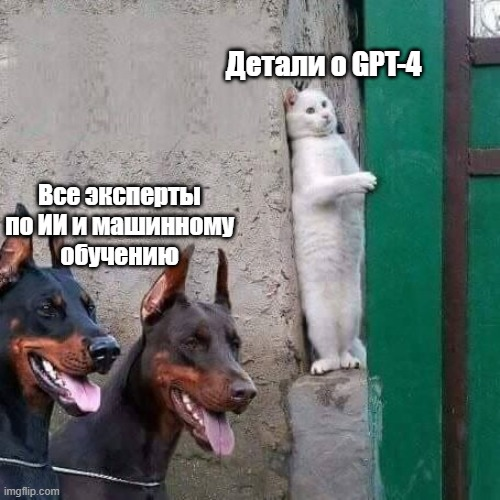

Обычно, когда выпускают новую модель – сразу публикуют и научную статью с описанием процесса исследований, обнаруженных проблем и способов их решения.

OpenAI не представили никаких деталей по модели: не опубликовали научную статью, техническую документацию, или хотя бы «карточку модели» (так называется таблица с основными характеристиками для сравнения, которая часто используется в индустрии нейронных сетей). Все, что нам досталось – это отчет на 100 страницах, где буквально говорится «Мы обучили модель на большом объеме данных». Почитайте технический отчет и будете, мягко говоря, разочарованы!

Из параметров достоверно известно, что максимальная длина промпта модели выросла до 32 тысяч токенов.



## Как происходит обучение GPT

Обучающий текст нарезается на случайные куски, которые составляются в последовательности из 1024 (2048 у GPT-3) токенов разделяясь специальным `<|endoftext|>` символом. Во время обучения, модель учится предсказывать (классифицировать) каждый токен в последовательности один за другим при помощь `CrossEntropy Loss.`

Так как входная последовательность всегда заполнена до конца, padding не используется. Но во время инференса, длина входного текста может быть произвольной, поэтому надо явно указывать чем паддить оставшиеся позиции. По дефолту использутеся тот же `<|endoftext|>`.

В кастомных версиях GPT вышесказанное может модифицироваться. Например, в ruGPT3 гораздо больше специальных токенов: `<s\>`, `<s>`, `<pad>`, `<unk>`

Что касается обучения визуального канала для GPT-4, то информации в отчетах OpenAI попросту нет.

## Немного о теории заговора

В мире ИТ также ходит много слухов, как и в любой другой сфере человеческой деятельности.

По одному из таких слухов, компания Google разработала прототип очень похожий на OpenAI Transformer ещё до OpenAI. Но скрыла тот факт, чтобы не плодить конкурента своему поисковику на базе BERT. Ставки на кодировщик были выше чем на декодировщик в компании Google и требовалось время.

По слухам один из авторов статьи Attention IIs All Need, Ноам Шазир, занимался разработкой чата Meena, и чат был готов раньше GPT и поискового движка на базе BERT, и его никак нельзя было публиковать для широкой публики. Причём по слухам, он в 2018 году был уже круче GPT-2. Ставки перевода всего поиска на модель BERT были высоки.

Кстати Шазир в 2021 году ушёл из Google  ради стартапа CharacterAI. Как не странно, но вся восьмерка изобретателей трансформера ушли из Google ради своих проектов. А в 2024 году Google купила CharacterAI за 2,7 млрд долларов. Так что Шазир, снова в Google. Ждём от Google новых прорывов!

Да, мы тоже верим слухам, а потому и написали про модель BERT раньше OpenAI transformer. Так как, работая над BERT, Google уже успела изучить и трансформеры на базе кодировщика и декодировщика, и имела представление, где модели могут "выстрелить". И большая восьмёрка изобретателей трансформера, потому и ушла из компании в стартапы, что понимала потенциал чат-ботов и где их знания будут востребованы.

Кстати и OpenAI, несмотря на то, что создавалась как открытая компания, обещавшая публиковать все исходники своих моделей, со временем, всё сильнее оберегает свои модели и уже к 4 модели gpt, сложно понять из отчётов компании, чем модель отличается от классического трансформера.

А теперь посмотрим, как мы можем [дообучить GPT-модель](https://colab.research.google.com/drive/1-cYTyr3KVz-oZ4EdAsGmmmw-N7qebAdZ) для своего проекта.